<!--- Made by:
      Oscar Antonio Restrepo Gutiérrez
--->

# Root-finding methods
There are countless problems in physics where you need to find the roots of an equation (the values at which the function equals zero); finding the roots of polynomials is relatively easy (thanks to the fundamental theorem of algebra), but if there are transcendental functions then only numerical methods can be used. The methods studied here are,

1. [The graphical method: Introduction](#Introduccion).
2. [The bisection method](#El_metodo_de_la_biseccion).
3. [The fixed-point method](#punto_fijo).
4. [The Newton-Raphson method](#Newton-Raphson).
5. [The secant method](#Metodo_de_la_secante).
6. [The false-position method](#Metodo_de_la_posicion_falsa).
7. [Steffensen's method](#Metodo_de_Steffensen).

Finally, at the end of the chapter we have,

8. [Exercises](#Ejercicios).
9. [Supplementary material](#Material_complementario).

<!---
1) Bisection algorithm    (2.1 The Bisection Method pag 48).  
2) Fixed-point algorithm      (2.2 Fixed-Point Iteration 56).<br>
3) Newton-Raphson algorithm  (2.3 Newton’s Method and Its Extensions, pag 67).<br>
4) Secant algorithm       (2.3 Newton’s Method and Its Extensions, pag 71).<br> 
5) False-position algorithm  (2.3 Newton’s Method and Its Extensions, pag 73.<br>
6) Steffensen algorithm.
--->

<a id='Introduccion'></a>
## 1) The graphical method: Introduction
Consider the following physics problem: there is a radioactive gas inside a container that lets particles migrate out at a constant rate $v$ (for example through a leak). If at time $t$ there are $N(t)$ particles decaying at a constant rate $\lambda$, then this gas is governed by the differential equation,
  $$\frac{dN(t)}{dt}= -\lambda N(t) - v,$$
the analytical solution to this problem is given by
  $$N(t)=N_0e^{-\lambda t}+\frac{v}{\lambda}(e^{-\lambda t}-1)$$
where $N_0$ is the initial number of particles. Suppose $N_0=10000$ and that at time $t=1\,$ ms the number of particles is reduced by half, $N=5000$; if the migration rate is $v=1$ particle per ms, what is the decay rate $\lambda$ of the radioactive particles? Substituting into the equation above we get,
  $$5000=10000e^{-\lambda}+\frac{1}{\lambda}(e^{-\lambda}-1)$$
This defines a transcendental equation with no possible analytical solution — how do we solve the problem then?
The following code shows the plot of

$$f(\lambda)=10000e^{-\lambda}+\frac{1}{\lambda}(e^{-\lambda}-1) -5000$$

in which the value of $\lambda$ is obtained when the function crosses the $x$ axis, i.e. $f(\lambda)=0$:


In [1]:
import numpy as np
import matplotlib.pyplot as plt


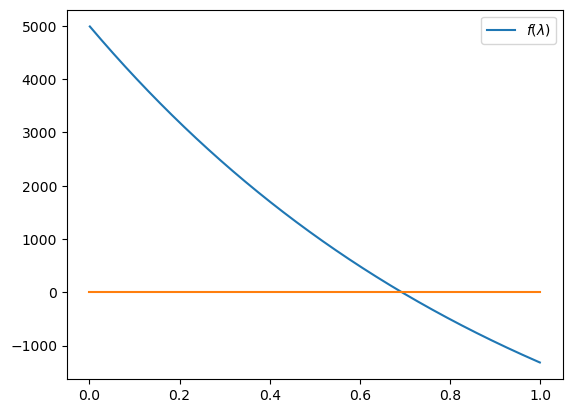

In [2]:
# radioactive decay function in a leaking flask (first problem)
f = lambda x: 1e4*np.exp(-x) + 1/x*(np.exp(-x)-1) - 5000
x=np.arange(0.001,1, 0.001) # values of lambda

plt.plot(x,f(x),label=r'$f(\lambda$)')    
plt.plot([0,1],[0,0]) # straight line at zero.
plt.legend()          # to show the labels. 

plt.show()


<a id='Ecuaciones_de_una_variable'></a>
### Single-variable equations
The previous question defines the problem of finding the roots of a single-variable function that is not a polynomial. By the fundamental theorem of algebra we know that every polynomial of degree $n$ has at most $n$ real or complex roots; in that case an analytical solution exists, but in cases like the introductory problem no analytical solution exists — these kinds of equations are known as transcendental. There are many classes of transcendental functions, for example:

   > a)  $f(x) =  x - \cos(x)$<br>
   > b)  $f(x) =  \tan(x) -x^2 + 2$<br>
   > c)  $f(x) =  0.10*\exp(x/5.0) + 5.0(\exp(x/5.0) - 1.2)$<br>

In these cases the roots can only be found approximately. There are several ways to find roots; the easiest is graphically, for example,

   $$f(x) = 0 = x - \cos(x)$$   
   $$x = \cos(x)$$

so you plot $x$ and then $\cos(x)$; the intersection point of the plots gives the root, ~0.73:


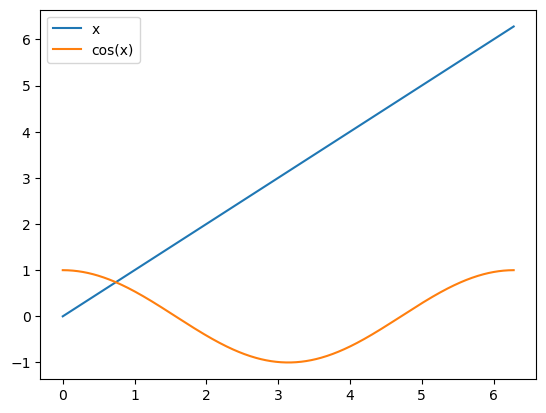

In [3]:
# %pylab, # 
# %matplotlib inline
#%matplotlib
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0,2*np.pi,0.01)
plt.plot(x,x, label="x")       # plot of x
plt.plot(x,np.cos(x),label='cos(x)') # plot of cos(x)
plt.legend() # to show the labels. 

plt.show()


This method is not very precise; note that the spacing in x is ~0.1,
but by using the zoom in the plot window we can get a first approximation of the root (or roots of the function); so from the plot we can get a first approximation with about 2 or 3 significant figures.
Likewise, for the radioactive decay case we see the root is where $f(\lambda)=0$; from the first plot we see $\lambda\approx 0.7$.

To find the roots with a better approximation there are several methods:


<a id='El_metodo_de_la_biseccion'></a>
## 2) The bisection method
 It's based on the intermediate value theorem, which states:
 
 If $f$ belongs to C$[a,b]$ (functions continuous on $[a,b]$) and $K$ is a number between $f(a)$ and $f(b)$, then there exists a number $c$ in $(a,b)$ such that $K = f(c)$.

 The method consists of selecting an interval $(a,b)$ that contains the root,
 note that $f(a)*f(b)<0$.
 Steps:

 1) Compute the midpoint of the interval and evaluate the function there:
   
   $$p = a + (b-a)/2 = (a+b)/2$$
 
 2) If $f(a)*f(p)>0$ then the root is in the interval $(p,b)$; we change $a = p$.<br>
 If $f(a)*f(p)<0$ then the root is in the interval $(a,p)$; we change $b = p$.
 
 3) Repeat the steps until any of these conditions holds:

   * $|p_n - p_{n-1}| < eps$,     (absolute error).
   
   * $|p_n - p_{n-1}|/|p_n|  < eps$, (percentage error, perhaps the best criterion).

   * $|f(p_n)| < eps$.           

The following plot shows convergence over three steps

|<img src="../figures/Biseccion.png" alt="Drawing" style="width: 500px;"/>|
|:--:| 
| *Figure: Bisection method (figure from Burden's book)*|

In general $|\epsilon-\epsilon'|$ is defined as the absolute error and $|\epsilon-\epsilon'|/|\epsilon|$ is the relative error, where $\epsilon$ is the true value and $\epsilon'$ the approximate value; nevertheless, in the cases above, $p_n$ is taken as the "true" value, since it is a better approximation to $p$ than $p_{n-1}$. Any of the three criteria can run into problems; for example, we know that if $f(p) = 0$ the root has already been found, but there will be functions for which $f(p_n) < eps$ and $|p_n - p| >> eps$, i.e. $p$ is far from the root.

 
The python code for the bisection algorithm is:


In [4]:
import numpy as np

# define the bisection algorithm
def Biseccion(f,a,b,eps):
   if (f(a)*f(b) > 0.0): 
     print("choose a better interval")
     return
   
   a1 = a                # initial values a and b
   b1 = b                # obtained from the plot 
   i = 0                 # iteration counter
   while True:
     i=i+1
     p = (a1 + b1)*.5    # midpoint between a and b
     print (i, p, f(p))  

     if (f(a1)*f(p) > 0.0): a1 = p 
     if (f(a1)*f(p) < 0.0): b1 = p

     if ( np.abs(f(p)) < eps ):break # stopping condition.


**Example 1**: Let's find the root of $f(x)=\cos(x)-x$, on $[0,1]$:  


In [5]:
Biseccion(lambda x: np.cos(x) -x,0,1.0, 1.0e-10)

# note the function could also have been defined as 

# def f1(x):
#    return cos(x)

# and then used as:
# Biseccion(f1 ,0,1.0, 1.0e-10)


1 0.5 0.37758256189037276
2 0.75 -0.018311131126179103
3 0.625 0.18596311950521793
4 0.6875 0.0853349461524715
5 0.71875 0.03387937241806649
6 0.734375 0.00787472545850132
7 0.7421875 -0.005195711743759213
8 0.73828125 0.001345149751805108
9 0.740234375 -0.001923872780897673
10 0.7392578125 -0.0002890091467900868
11 0.73876953125 0.0005281584336581657
12 0.739013671875 0.00011959667132188656
13 0.7391357421875 -8.470073137478717e-05
14 0.73907470703125 1.7449346639941687e-05
15 0.739105224609375 -3.362534821038654e-05
16 0.7390899658203125 -8.087914744714375e-06
17 0.7390823364257812 4.680737457851691e-06
18 0.7390861511230469 -1.7035832658995886e-06
19 0.7390842437744141 1.488578440400623e-06
20 0.7390851974487305 -1.0750207668497325e-07
21 0.7390847206115723 6.905382659017079e-07
22 0.7390849590301514 2.915181156470936e-07
23 0.7390850782394409 9.200802475461956e-08
24 0.7390851378440857 -7.747024688420368e-09
25 0.7390851080417633 4.213050031065535e-08
26 0.7390851229429245 1.719173

**Exercise**: Plot and find the root of $f(x)=\tan(x)-x^2$ on $[1.55, 165]$. Why does it give an infinite loop?


In [6]:
# Biseccion(lambda x: np.tan(x) -x**2.0,1.55,1.65, 1.0e-10)
# IMPORTANT: to stop the loop, in Kernel select interrupt!
